<a href="https://colab.research.google.com/github/radhikatbbt/Radhika_ACMResearchTasks-/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dawindersharma/netflix-movies-and-tv-shows-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(path + "/netflix_titles.csv")

Using Colab cache for faster access to the 'netflix-movies-and-tv-shows-dataset' dataset.
Path to dataset files: /kaggle/input/netflix-movies-and-tv-shows-dataset


In [31]:
df = pd.read_csv(path + "/netflix_titles.csv")
df.shape

(8807, 12)

### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [33]:
df.columns
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [32]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [34]:
df = df.dropna(subset=['director', 'country'])

In [35]:
df[['director', 'country']].isnull().sum()

,0
director,0
country,0


## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [38]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5751 non-null   object        
 1   type          5751 non-null   object        
 2   title         5751 non-null   object        
 3   director      5751 non-null   object        
 4   cast          5336 non-null   object        
 5   country       5751 non-null   object        
 6   date_added    5746 non-null   datetime64[ns]
 7   release_year  5751 non-null   int64         
 8   rating        5750 non-null   object        
 9   duration      5748 non-null   object        
 10  listed_in     5751 non-null   object        
 11  description   5751 non-null   object        
 12  year_added    5746 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 629.0+ KB


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [40]:
df['duration_minutes'] = (
    df['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)
movies = df[df['type'] == 'Movie']
top_5_longest = movies.sort_values(
    by='duration_minutes',
    ascending=False
).head(5)

## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

Movies make up a larger section of content on netflix

In [41]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,5562
TV Show,189


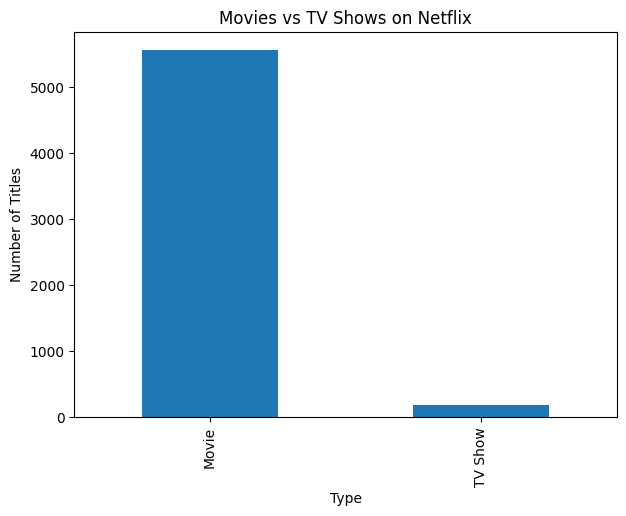

In [42]:
plt.figure(figsize=(7,5))

type_counts.plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Number of Titles')

plt.show()

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [43]:
countries = df['country'].str.split(', ').explode()

In [44]:
top_5_countries = countries.value_counts().head(5)
top_5_countries

,count
country,
United States,2749
India,961
United Kingdom,537
Canada,317
France,311


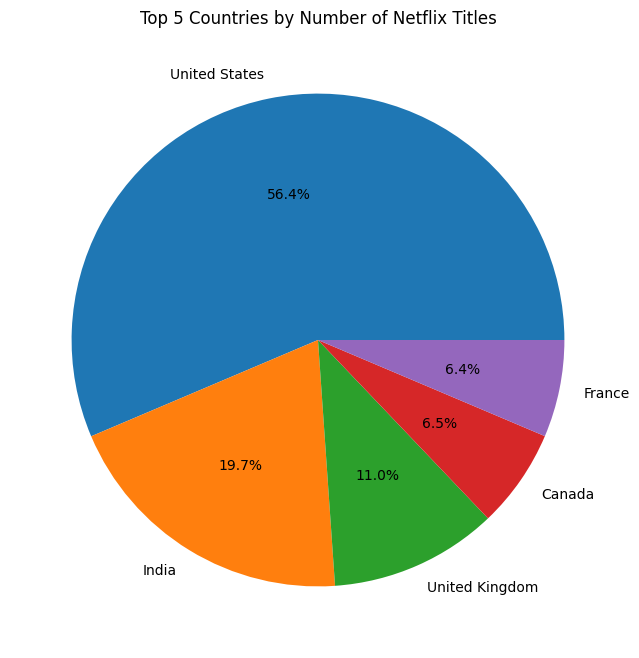

In [45]:
plt.figure(figsize=(8,8))

plt.pie(
    top_5_countries.values,
    labels=top_5_countries.index,
    autopct='%1.1f%%'
)

plt.title('Top 5 Countries by Number of Netflix Titles')

plt.show()

THE U.S IS THE TOP CONTRIBUTOR AMONG TOP 5 COUNTRIES FOLLOWED BY INDIA AND U.K, WITH A MUCH SMALLER PORTION

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [47]:
genre_country = df[['country', 'listed_in']].copy()
genre_country['country'] = genre_country['country'].str.split(', ')
genre_country['listed_in'] = genre_country['listed_in'].str.split(', ')

In [48]:
genre_country = genre_country.explode('country')
genre_country = genre_country.explode('listed_in')

In [49]:
genre_country_counts = (
    genre_country
    .groupby(['listed_in', 'country'])
    .size()
    .reset_index(name='count')
)

In [50]:
idx = genre_country_counts.groupby('listed_in')['count'].idxmax()

genre_leaders = genre_country_counts.loc[idx]

In [53]:
for _row in genre_leaders.iterrows():
    print(f"{row['listed_in']} -> {row['country']} ({row['count']} titles)")

Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)
Thrillers -> United States (292 titles)


## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

In [54]:
titles_per_year = df['year_added'].value_counts().sort_index()
titles_per_year

,count
year_added,
2008.0,1
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,7
2014.0,18
2015.0,56
2016.0,240


Netflix added most catalouges in the year 2019, and as similar numbers in 2020.

## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

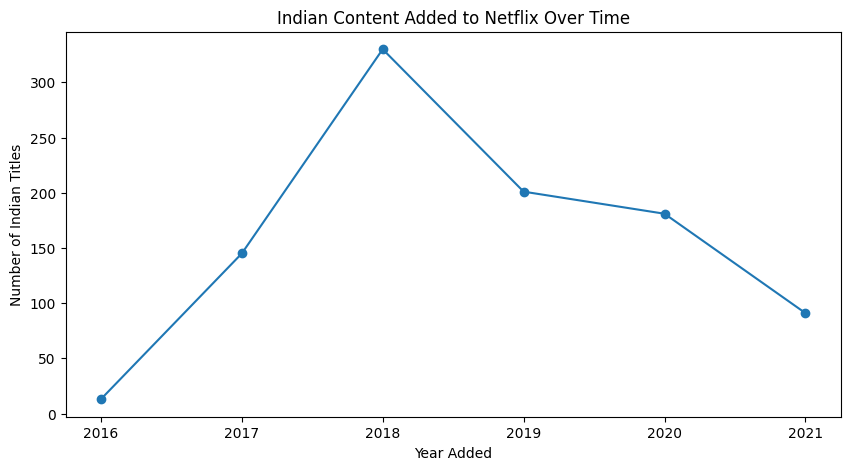

In [56]:
india = df[df['country'].str.contains('India', case=False, na=False)]
india_year = india['year_added'].value_counts().sort_index()
india_year.plot(kind='line', marker='o', figsize=(10,5), title='Indian Content Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Indian Titles')
plt.show()

The above graph showcases presence of India's content on netflix. It increased till 2018, and shows a decline afterward. 2018 is the year where Netflix had the strongest Indian presence